In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
from lib_3d_OT.utils import *

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



In [2]:
adata=sc.read_h5ad('//home/dbj/lib_3d_OT/revise/scGPT/673-embedding.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 3610 × 512
    obs: 'in_tissue', 'array_row', 'array_col', 'truth'
    uns: 'hvg', 'spatial'
    obsm: 'spatial'

In [6]:
clustering(adata, n_clusters=7, radius=50, key='X', method='mclust', refinement=True,random=2024,n_comp=40)

fitting ...
  |======================================================================| 100%


In [23]:
sc.settings.figdir = '/home/dbj/lib_3d_OT/revise/scGPT/'

/home/dbj/anaconda3/envs/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


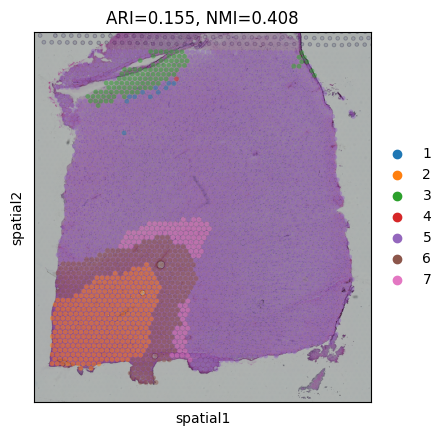

In [10]:
sc.pl.spatial(adata, color='3d-OT', img_key='hires',title='ARI=0.155, NMI=0.408', alpha=0.5, size=1.3,save='scGPT673.png')

In [9]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ARI = adjusted_rand_score(adata.obs['truth'], adata.obs['3d-OT'])
NMI = normalized_mutual_info_score(adata.obs['truth'], adata.obs['3d-OT'])
ARI,NMI

(0.15458635482521527, 0.40788659688634243)

In [15]:
adata=sc.read_h5ad('/home/dbj/lib_3d_OT/revise/scGPT/674-embedding.h5ad')

In [16]:
adata

AnnData object with n_obs × n_vars = 3634 × 512
    obs: 'in_tissue', 'array_row', 'array_col', 'truth'
    uns: 'hvg', 'spatial'
    obsm: 'spatial'

In [17]:
clustering(adata, n_clusters=7, radius=50, key='X', method='mclust', refinement=True,random=2024,n_comp=20)

fitting ...
  |======================================================================| 100%


/home/dbj/anaconda3/envs/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


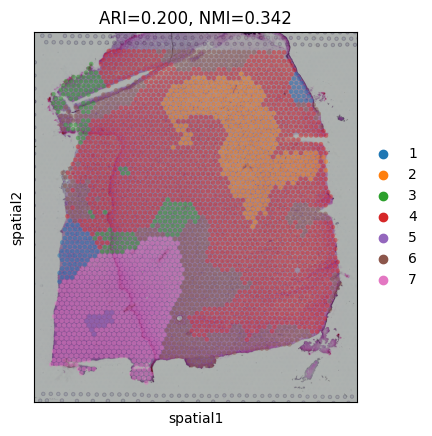

In [19]:
sc.pl.spatial(adata, color='3d-OT', img_key='hires',title='ARI=0.200, NMI=0.342', alpha=0.5, size=1.3,save='scGPT674.png')

In [18]:
from sklearn.metrics import adjusted_rand_score,normalized_mutual_info_score
ARI = adjusted_rand_score(adata.obs['truth'], adata.obs['3d-OT'])
NMI = normalized_mutual_info_score(adata.obs['truth'], adata.obs['3d-OT'])
ARI,NMI

(0.20003224787322196, 0.34198224889674333)

In [29]:
adata1=sc.read_h5ad('/home/dbj/lib_3d_OT/revise/scGPT/mousebrain-embedding.h5ad')

In [30]:
clustering(adata1, n_clusters=18, key='X', method='mclust',random=2024,n_comp=20)

fitting ...
  |======================================================================| 100%


/home/dbj/anaconda3/envs/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/dbj/anaconda3/envs/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


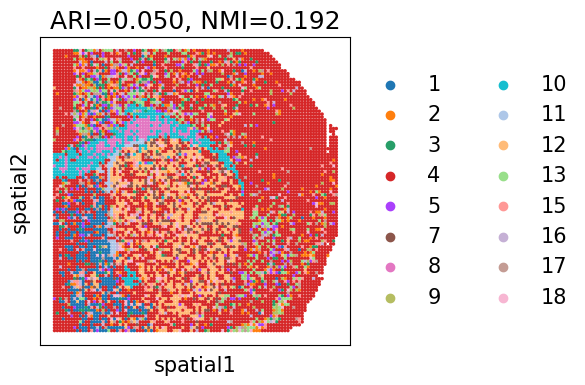

In [34]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata1,basis='spatial',color='3d-OT',title='ARI=0.050, NMI=0.192',size=25,ax=ax,save='scGPTmousebrain.png')

/home/dbj/anaconda3/envs/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/dbj/anaconda3/envs/py310/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


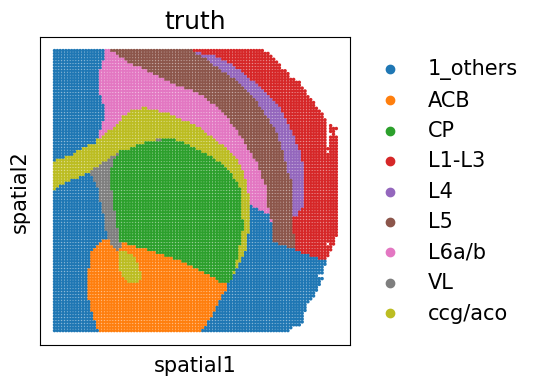

In [32]:
adata=sc.read_h5ad('/home/dbj/mouse/spatialglue_alldata/Dataset7_Mouse_Brain_ATAC/3d-OT.h5ad')
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['font.size'] = 15

fig, ax = plt.subplots()
sc.pl.embedding(adata,basis='spatial',color='truth',size=25,ax=ax,save='truth.png')

In [33]:
import numpy as np
from sklearn.metrics import (homogeneity_score,mutual_info_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score
)

true_labels = np.array(adata.obs['truth'])
cluster_labels = np.array(adata1.obs['3d-OT'])

homogeneity = homogeneity_score(true_labels, cluster_labels)
mutual_info = mutual_info_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("Homogeneity:", homogeneity)
print("Mutual Information:", mutual_info)
print("V-Measure:", v_measure)
print("AMI:", ami)
print("NMI:", nmi)
print("ARI:", ari)

Homogeneity: 0.18458733459296295
Mutual Information: 0.36877212639299606
V-Measure: 0.19187139582930973
AMI: 0.1890616927652812
NMI: 0.1918713958293097
ARI: 0.049673159142718686
